In [1]:
# ============================================================
# PHASE 5: Machine Learning Models + SHAP Explainability
# Models: Decision Tree, Random Forest, XGBoost
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              ConfusionMatrixDisplay, f1_score)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries loaded ✅")

All libraries loaded ✅


In [2]:
df = pd.read_csv('../data/cleaned/telco_churn_cleaned.csv')

# ── Encode binary columns ──────────────────────────────────
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'Churn', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                            'No phone service': 0,
                            'No internet service': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

df = pd.get_dummies(df,
                    columns=['Contract', 'PaymentMethod', 'InternetService'],
                    drop_first=True)

df.drop(columns=['customerID', 'TotalCharges'], inplace=True)

# ── Features & Target ──────────────────────────────────────
X = df.drop(columns=['Churn'])
y = df['Churn']

# ── Train-Test Split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Features shape :", X.shape)
print("Training size  :", X_train.shape)
print("Testing size   :", X_test.shape)
print("\nChurn balance in train set:")
print(y_train.value_counts())

Features shape : (7032, 22)
Training size  : (5625, 22)
Testing size   : (1407, 22)

Churn balance in train set:
Churn
0    4130
1    1495
Name: count, dtype: int64


In [7]:
# Reusable evaluation function for all 3 models
def evaluate_model(name, model, X_test, y_test):
    y_pred      = model.predict(X_test)
    y_proba     = model.predict_proba(X_test)[:, 1]
    auc         = roc_auc_score(y_test, y_proba)
    f1          = f1_score(y_test, y_pred)

    print("=" * 50)
    print(f"  MODEL: {name}")
    print("=" * 50)
    print(classification_report(y_test, y_pred,
                                  target_names=['No Churn', 'Churn']))
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print("=" * 50)

    return y_pred, y_proba, auc, f1

In [8]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_pred, dt_proba, dt_auc, dt_f1 = evaluate_model(
    "Decision Tree", dt, X_test, y_test
)

  MODEL: Decision Tree
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1033
       Churn       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407

  ROC-AUC : 0.8196
  F1 Score: 0.5884


In [9]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred, rf_proba, rf_auc, rf_f1 = evaluate_model(
    "Random Forest", rf, X_test, y_test
)

  MODEL: Random Forest
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.64      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

  ROC-AUC : 0.8337
  F1 Score: 0.5642


In [10]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

xgb_pred, xgb_proba, xgb_auc, xgb_f1 = evaluate_model(
    "XGBoost", xgb, X_test, y_test
)

  MODEL: XGBoost
              precision    recall  f1-score   support

    No Churn       0.83      0.88      0.85      1033
       Churn       0.60      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

  ROC-AUC : 0.8275
  F1 Score: 0.5562


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost'      : xgb
}

print("5-Fold Cross Validation ROC-AUC Scores")
print("=" * 45)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:20s} → Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")

5-Fold Cross Validation ROC-AUC Scores
Decision Tree        → Mean: 0.8245  Std: 0.0042
Random Forest        → Mean: 0.8437  Std: 0.0034
XGBoost              → Mean: 0.8381  Std: 0.0037


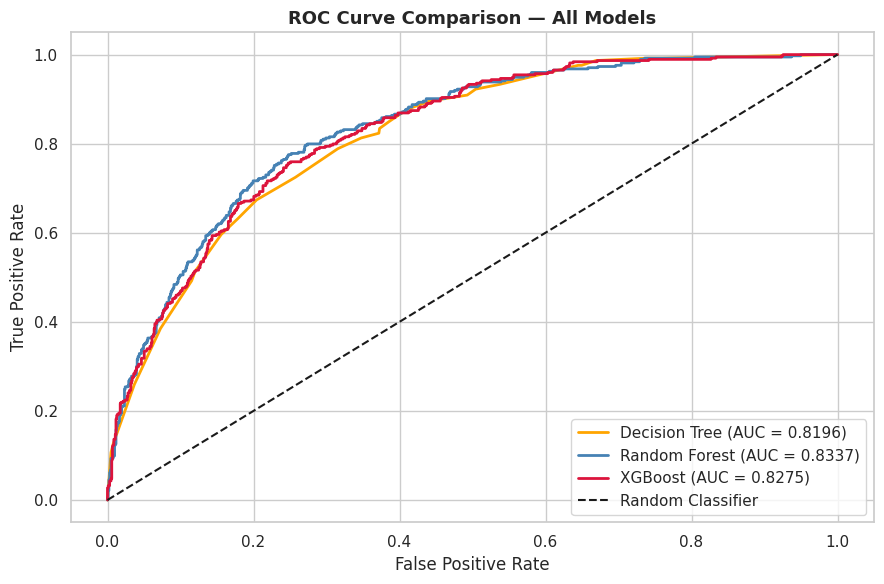

In [12]:
plt.figure(figsize=(9, 6))

for name, proba, color in zip(
    ['Decision Tree', 'Random Forest', 'XGBoost'],
    [dt_proba, rf_proba, xgb_proba],
    ['orange', 'steelblue', 'crimson']
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/roc_comparison.png', dpi=150)
plt.show()

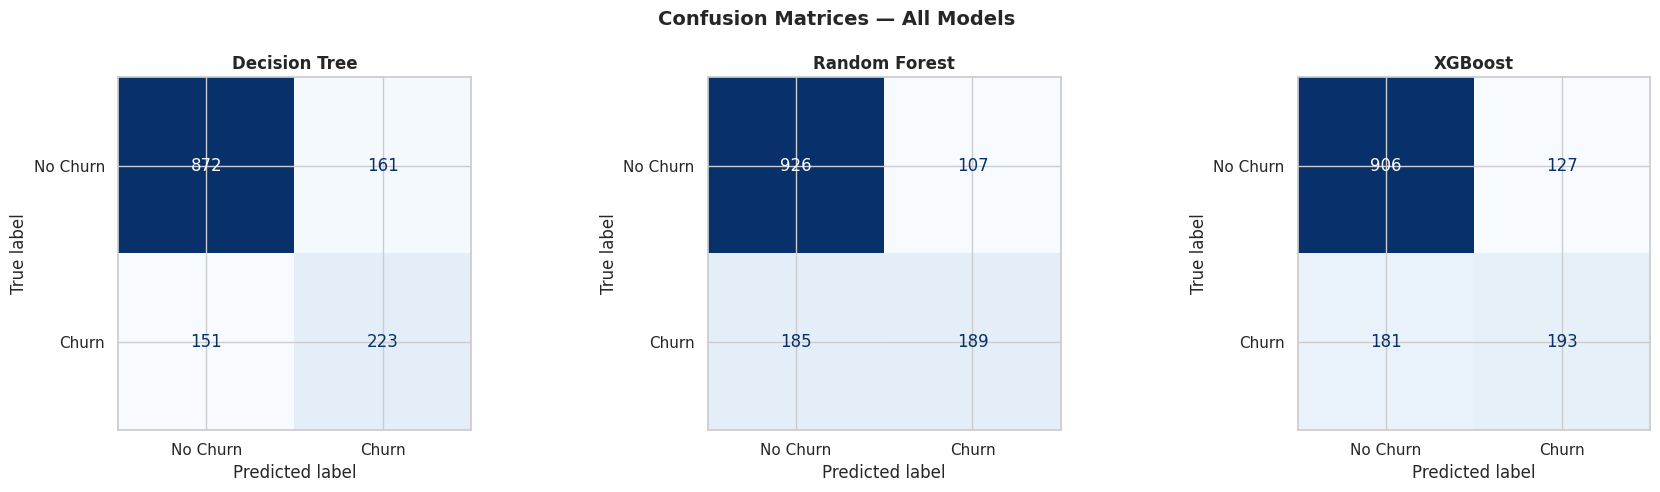

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name, pred in zip(
    axes,
    ['Decision Tree', 'Random Forest', 'XGBoost'],
    [dt_pred, rf_pred, xgb_pred]
):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrices_all.png', dpi=150)
plt.show()

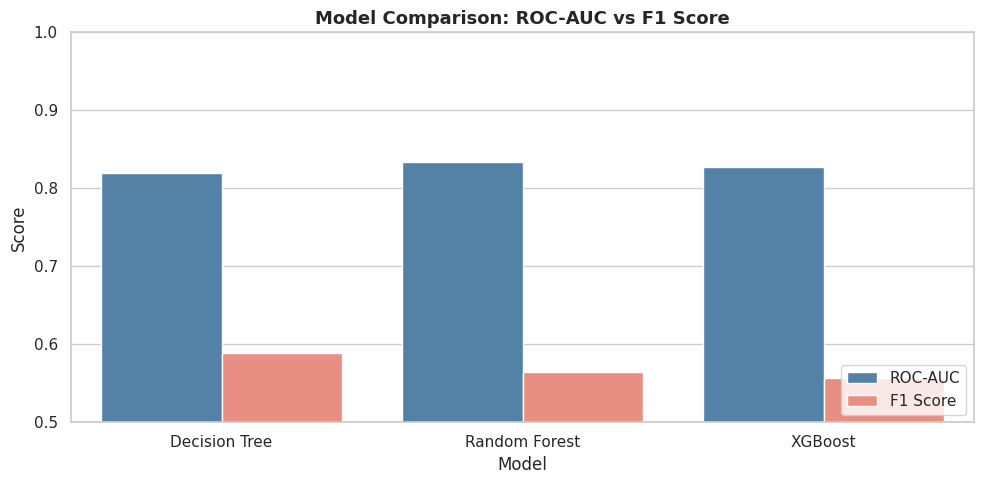

        Model  ROC-AUC  F1 Score
Decision Tree 0.819565  0.588391
Random Forest 0.833733  0.564179
      XGBoost 0.827510  0.556196


In [14]:
comparison_df = pd.DataFrame({
    'Model'  : ['Decision Tree', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [dt_auc, rf_auc, xgb_auc],
    'F1 Score': [dt_f1, rf_f1, xgb_f1]
})

comparison_melted = comparison_df.melt(id_vars='Model',
                                        var_name='Metric',
                                        value_name='Score')

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_melted, x='Model', y='Score',
            hue='Metric', palette=['steelblue', 'salmon'])
plt.ylim(0.5, 1.0)
plt.title('Model Comparison: ROC-AUC vs F1 Score',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png', dpi=150)
plt.show()

print(comparison_df.to_string(index=False))

🚀 Calculating SHAP values (this may take a minute)...


 93%|=================== | 1303/1407 [00:11<00:00]       

SHAP values computed ✅
Shape: (1407, 22)


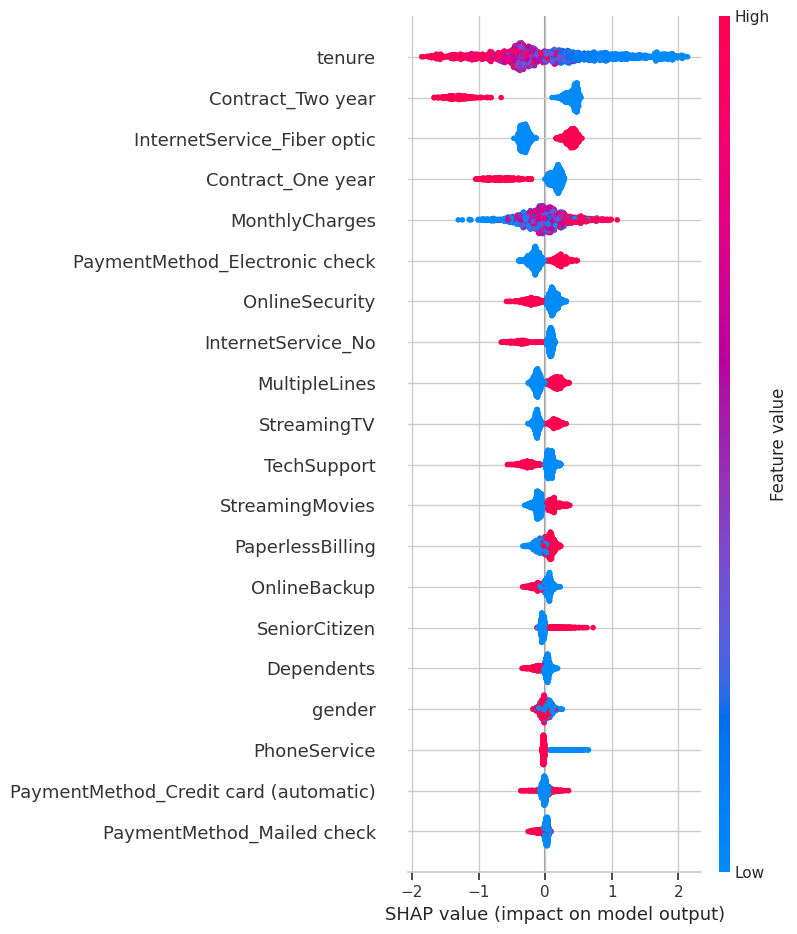

In [16]:
import shap
import pandas as pd

# 1. Force data to numeric (Required to fix your TypeError)
# .astype(float) converts Booleans to 1/0 and numeric strings to floats
X_train_numeric = X_train.astype(float)
X_test_numeric  = X_test.astype(float)

print("🚀 Calculating SHAP values (this may take a minute)...")

# 2. Use the TreeExplainer explicitly for XGBoost speed
# Passing X_train_numeric as the 'masker' helps SHAP define the "background"
explainer = shap.TreeExplainer(xgb, X_train_numeric)

# 3. Calculate SHAP values
# If X_test is huge, use X_test_numeric.iloc[:100] to make it instant
shap_values = explainer(X_test_numeric)

print("SHAP values computed ✅")
print("Shape:", shap_values.shape)

# 4. Immediate Visual Feedback
shap.summary_plot(shap_values, X_test_numeric)

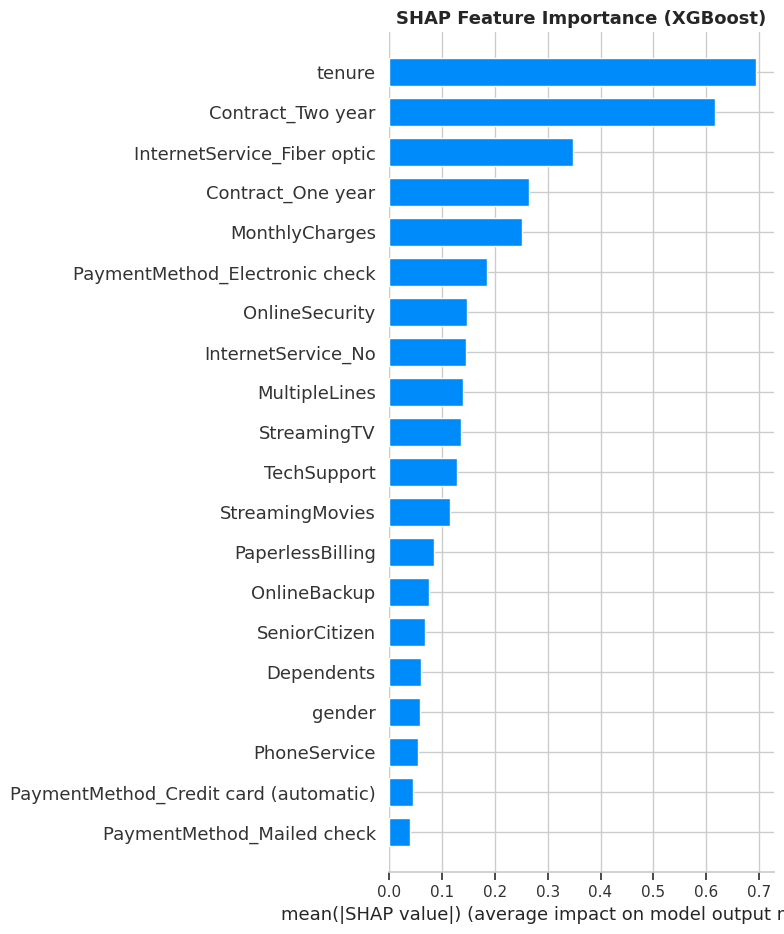

In [17]:
plt.figure()
shap.summary_plot(shap_values, X_test,
                  plot_type="bar",
                  show=False)
plt.title("SHAP Feature Importance (XGBoost)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

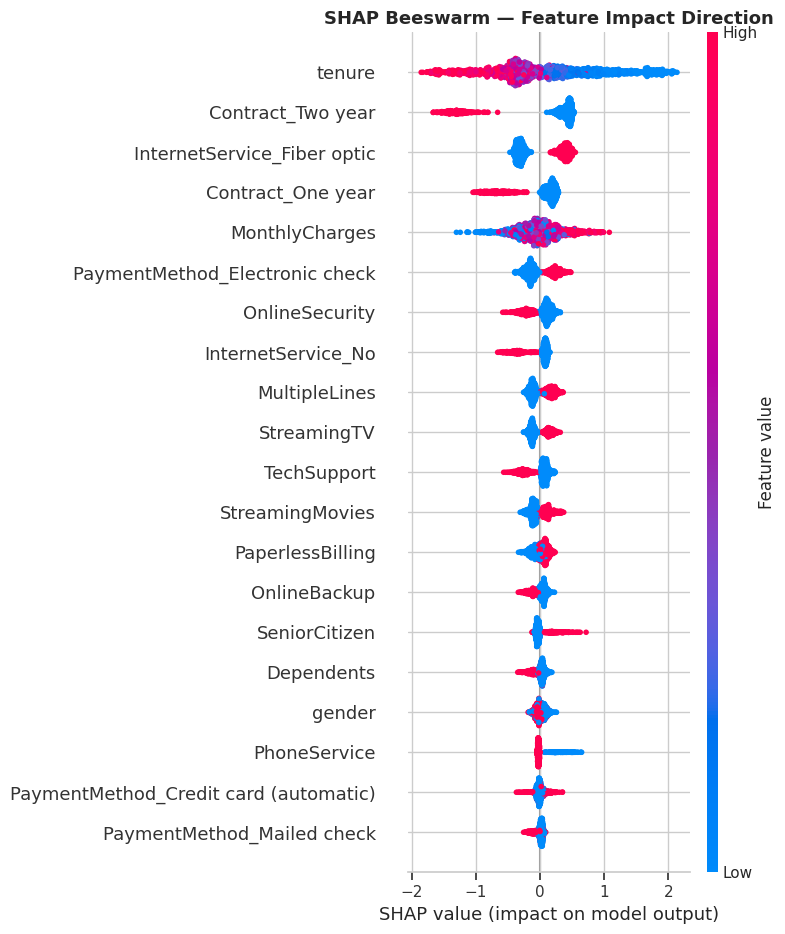

In [18]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm — Feature Impact Direction",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()

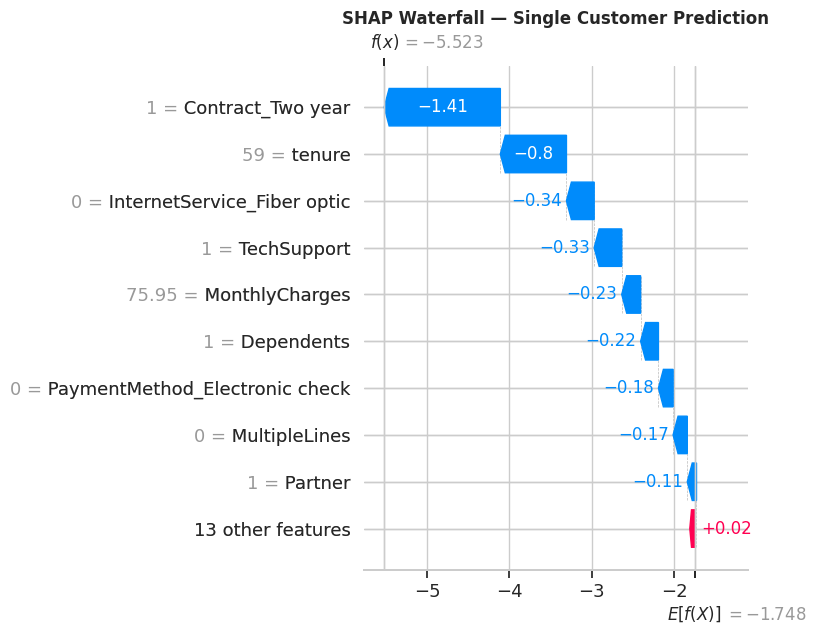

In [19]:
# Explain prediction for the first test customer
plt.figure()
shap.plots.waterfall(shap_values[0], show=False)
plt.title("SHAP Waterfall — Single Customer Prediction",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [20]:
final_metrics = pd.DataFrame({
    'Model'    : ['Decision Tree', 'Random Forest', 'XGBoost'],
    'ROC_AUC'  : [round(dt_auc, 4), round(rf_auc, 4), round(xgb_auc, 4)],
    'F1_Score' : [round(dt_f1, 4),  round(rf_f1, 4),  round(xgb_f1, 4)],
    'CV_AUC_Mean': [
        round(cv_results['Decision Tree'].mean(), 4),
        round(cv_results['Random Forest'].mean(), 4),
        round(cv_results['XGBoost'].mean(), 4)
    ]
})

final_metrics.to_csv('../outputs/model_metrics/ml_model_results.csv', index=False)

print("Final metrics saved ✅")
print(final_metrics.to_string(index=False))

Final metrics saved ✅
        Model  ROC_AUC  F1_Score  CV_AUC_Mean
Decision Tree   0.8196    0.5884       0.8245
Random Forest   0.8337    0.5642       0.8437
      XGBoost   0.8275    0.5562       0.8381
